In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error

# Modelos
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# --- 1. CONFIGURAÇÃO DA API E DOWNLOAD ---
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_dca9bae365f3c5067abe861522feb7bf'
!pip install -q kaggle
!kaggle datasets download -d laotse/credit-risk-dataset
!unzip -o credit-risk-dataset.zip

# --- 2. CARREGAMENTO E TRADUÇÃO DAS COLUNAS ---
df = pd.read_csv('credit_risk_dataset.csv')

traducao = {
    'person_age': 'idade',
    'person_income': 'renda_anual',
    'person_home_ownership': 'tipo_moradia',
    'person_emp_length': 'tempo_emprego',
    'loan_intent': 'motivo_emprestimo',
    'loan_grade': 'nota_risco_banco',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros',
    'loan_status': 'alvo_inadimplente',
    'loan_percent_income': 'percentual_comprometimento_renda',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'tempo_historico_credito'
}
df = df.rename(columns=traducao)

# --- 3. TRATAMENTO DE DADOS NULOS ---
df['taxa_juros'] = df['taxa_juros'].fillna(df['taxa_juros'].median())
df['tempo_emprego'] = df['tempo_emprego'].fillna(df['tempo_emprego'].median())

# Transformar variáveis de texto em números usando One-Hot Encoding
df_processado = pd.get_dummies(df, drop_first=True)

print("✅ Dados carregados, traduzidos e pré-processados com sucesso!")

Dataset URL: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
License(s): CC0-1.0
credit-risk-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  credit-risk-dataset.zip
  inflating: credit_risk_dataset.csv  
✅ Dados carregados, traduzidos e pré-processados com sucesso!


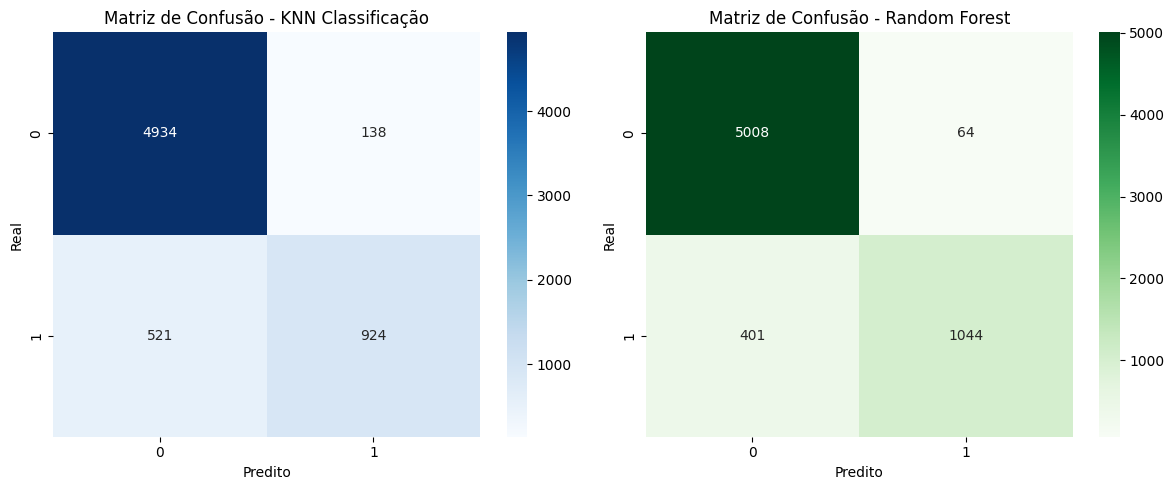


--- RELATÓRIO KNN ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      5072
           1       0.87      0.64      0.74      1445

    accuracy                           0.90      6517
   macro avg       0.89      0.81      0.84      6517
weighted avg       0.90      0.90      0.89      6517


--- RELATÓRIO RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.94      0.72      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.93      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517



In [6]:
# --- PARTE I: Classificação (Prever alvo_inadimplente) + Gráficos

# Separar dados
X_claf = df_processado.drop(columns=['alvo_inadimplente'])
y_claf = df_processado['alvo_inadimplente']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_claf, y_claf, test_size=0.2, random_state=42)

# Normalização (Essencial para o KNN)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Treinar KNN Classificação
knn_claf = KNeighborsClassifier(n_neighbors=5)
knn_claf.fit(X_train_c_scaled, y_train_c)
pred_knn_c = knn_claf.predict(X_test_c_scaled)

# Treinar Random Forest Classificação
rf_claf = RandomForestClassifier(random_state=42)
rf_claf.fit(X_train_c, y_train_c)
pred_rf_c = rf_claf.predict(X_test_c)

# --- VISUALIZAÇÃO DOS RESULTADOS (GRÁFICOS OBRIGATÓRIOS) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Confusão - KNN
sns.heatmap(confusion_matrix(y_test_c, pred_knn_c), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão - KNN Classificação')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

# Matriz de Confusão - Random Forest
sns.heatmap(confusion_matrix(y_test_c, pred_rf_c), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz de Confusão - Random Forest')
ax[1].set_xlabel('Predito')
ax[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print("\n--- RELATÓRIO KNN ---")
print(classification_report(y_test_c, pred_knn_c))
print("\n--- RELATÓRIO RANDOM FOREST ---")
print(classification_report(y_test_c, pred_rf_c))

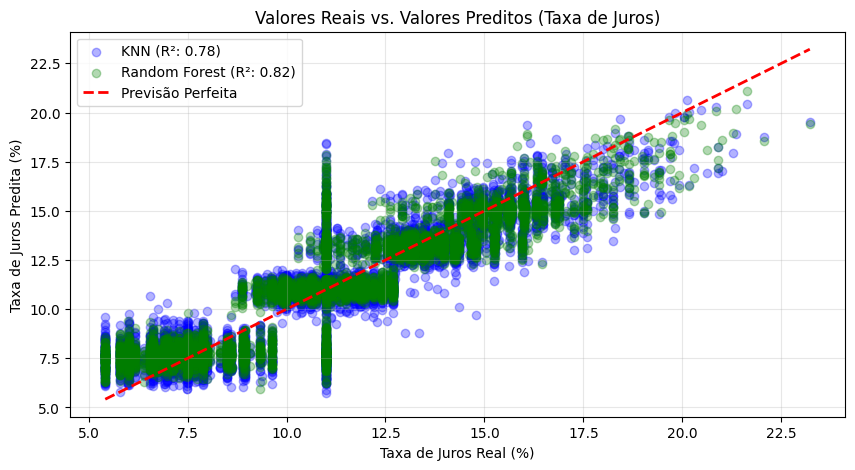

         PAINEL DE MÉTRICAS DE REGRESSÃO         
🌲 RANDOM FOREST REGRESSOR:
   -> RMSE (Erro Médio Real): 1.3279%
   -> R² Score (Precisão Geral): 0.8190
--------------------------------------------------
🔵 KNN REGRESSÃO:
   -> RMSE (Erro Médio Real): 1.4482%
   -> R² Score (Precisão Geral): 0.7848


In [9]:
# --- PARTE II: Regressão (Prever taxa_juros) + Gráficos ---

# Separar dados (taxa_juros agora é o alvo)
X_reg = df_processado.drop(columns=['taxa_juros'])
y_reg = df_processado['taxa_juros']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Normalização
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Treinar KNN Regressão
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r_scaled, y_train_r)
pred_knn_r = knn_reg.predict(X_test_r_scaled)

# Treinar Random Forest Regressão
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_r, y_train_r)
pred_rf_r = rf_reg.predict(X_test_r)

# --- VISUALIZAÇÃO DOS RESULTADOS (GRÁFICOS OBRIGATÓRIOS) ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test_r, pred_knn_r, alpha=0.3, label=f'KNN (R²: {r2_score(y_test_r, pred_knn_r):.2f})', color='blue')
plt.scatter(y_test_r, pred_rf_r, alpha=0.3, label=f'Random Forest (R²: {r2_score(y_test_r, pred_rf_r):.2f})', color='green')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Previsão Perfeita')
plt.title('Valores Reais vs. Valores Preditos (Taxa de Juros)')
plt.xlabel('Taxa de Juros Real (%)')
plt.ylabel('Taxa de Juros Predita (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- CÁLCULO DAS MÉTRICAS ---
rmse_knn = np.sqrt(mean_squared_error(y_test_r, pred_knn_r))
rmse_rf = np.sqrt(mean_squared_error(y_test_r, pred_rf_r))

print("=" * 50)
print("         PAINEL DE MÉTRICAS DE REGRESSÃO         ")
print("=" * 50)
print(f"🌲 RANDOM FOREST REGRESSOR:")
print(f"   -> RMSE (Erro Médio Real): {rmse_rf:.4f}%")
print(f"   -> R² Score (Precisão Geral): {r2_score(y_test_r, pred_rf_r):.4f}")
print("-" * 50)
print(f"🔵 KNN REGRESSÃO:")
print(f"   -> RMSE (Erro Médio Real): {rmse_knn:.4f}%")
print(f"   -> R² Score (Precisão Geral): {r2_score(y_test_r, pred_knn_r):.4f}")
print("=" * 50)